# import pips

In [32]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [33]:
valid_data = tf.keras.utils.image_dataset_from_directory(
    'valid',                    # Path to validation folder
    label_mode='categorical',   # Multi-class (38 classes → one-hot)
    image_size=(224, 224),      # Resize images
    batch_size=32,              # 32 images per batch
    shuffle=False               # No need to shuffle validation data
)

Found 6762 files belonging to 13 classes.


In [34]:
class_name = valid_data.class_names
class_name

['Chilo zacconius',
 'Chloropidae',
 'Chlorops pumilionis',
 'Cnaphalocrocis medinalis',
 'Gout fly',
 'Orseolia oryzae',
 'Oscinella frit',
 'Rice Leafroller',
 'UNKNOWN',
 'green leafhopper',
 'lo zacconius',
 'rice water weevil',
 'striped stem borer']

# Load Fusion Model

In [35]:
fusion = tf.keras.models.load_model("f2.keras", compile=False)

visual Image

<>:3: SyntaxWarning: invalid escape sequence '\G'
<>:3: SyntaxWarning: invalid escape sequence '\G'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_520\2603206120.py:3: SyntaxWarning: invalid escape sequence '\G'
  image_path = 'Valid\Gout fly\C.jpg'


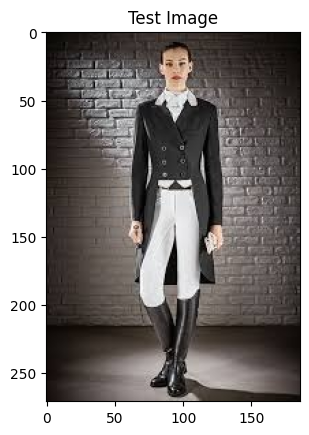

In [40]:
#Test Image Visualization
import cv2
image_path = 'Valid\Gout fly\C.jpg'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')

plt.show()

Test Model

In [41]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(224,224))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = fusion.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [42]:
print(predictions)

[[7.1807826e-06 2.0841742e-06 8.6511886e-07 5.9903380e-07 4.9955706e-06
  1.5735067e-06 2.0297100e-06 7.5673533e-08 9.9997115e-01 5.2450578e-06
  2.7778326e-06 6.9434822e-07 6.7022415e-07]]


In [43]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

8


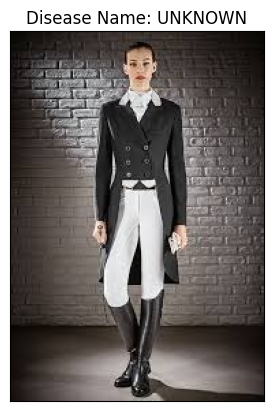

In [44]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()